# 03 — Vehicle Subset, Fold Assignment & Out-of-Sample Baselines

**Project:** EV Battery Capacity Prediction

Runs on artefacts from `01_data_ingestion.ipynb` and `02_eda.ipynb`.

---

## Purpose

This notebook produces the **evaluation protocol** that every model in this project —
baselines, LSTM and Transformer alike — will be measured under. Nothing downstream is
comparable unless it runs against the folds fixed here.

Three outputs:

1. A **30-vehicle subset**, selected to be representative rather than arbitrary
2. A **5-fold cross-validation assignment** at the vehicle level, saved to disk
3. **Out-of-sample baseline scores** — the definitive figures for the results table

## Why the baselines are recomputed here

The baseline figures in notebook 02 were computed **in-sample**: fitted on all 349,741
snippets and evaluated on those same snippets. The reference paper's LSTM (RMSE 1.420)
was evaluated on held-out data.

Comparing the two would be unfair to the LSTM. The figures below are computed the same
way the paper's were — fitted on training vehicles, evaluated on vehicles never seen —
and on **identical folds** to the ones the neural networks will use.

This last point is the important one. Given the 23× imbalance in per-vehicle snippet
counts (notebook 01, Finding A) and the distinct per-vehicle degradation trajectories
(notebook 02, Finding 4), a difference between two models evaluated on *different*
splits could easily be a difference in which vehicles happened to land in test.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
N_CARS = 30          # vehicles in the working subset
N_FOLDS = 5          # cross-validation folds

rng = np.random.default_rng(RANDOM_SEED)

INDEX_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(INDEX_DIR / "dataset_index.json") as fp:
    index = json.load(fp)

car_to_files = index["car_to_files"]
cars_df = pd.read_csv(INDEX_DIR / "car_summary.csv")
snips = pd.read_csv(INDEX_DIR / "snippet_meta.csv")

print(f"Vehicles available : {len(cars_df)}")
print(f"Snippets available : {len(snips):,}")

Vehicles available : 100
Snippets available : 349,741


## 1. Selecting 30 vehicles

### Why subset at all

All 100 vehicles give 349,741 snippets. With 5-fold CV, each architecture is trained
5 times — and during development each will be retrained many times over while tuning.
Roughly 105k snippets from 30 vehicles is ample for models of this size, and the
accuracy difference is small relative to the compute saved.

The full index is retained, so scaling up later is a one-line change.

### How to select them

Two properties from earlier findings constrain the choice:

**Cannot stratify by mileage.** (Notebook 01, Finding D.) Nearly every vehicle spans
low, medium and high mileage individually, so mileage is not a per-vehicle property to
balance on. Any reasonable set of vehicles will cover the mileage range.

**Should stratify by snippet count.** (Notebook 01, Finding A.) Counts range 390 to
9,101 — a 23× spread. Taking 30 vehicles at random risks landing on a cluster of
data-rich or data-poor ones, which would make the subset unrepresentative of the fleet.

So: sort vehicles by snippet count, divide into 30 equal-sized strata, and draw one
vehicle at random from each. This guarantees the subset spans the full range of data
volumes while remaining random within each stratum.

In [2]:
# Stratified selection across snippet-count deciles.
# Sorting then splitting into N_CARS equal groups and drawing one from each
# guarantees coverage of the full 390-9,101 range of per-vehicle data volumes.

ordered = cars_df.sort_values("n_snippets").reset_index(drop=True)
strata = np.array_split(np.arange(len(ordered)), N_CARS)

picked_idx = [int(rng.choice(s)) for s in strata]
subset = ordered.iloc[picked_idx].sort_values("car").reset_index(drop=True)

print(f"Selected {len(subset)} vehicles")
print(f"Snippets : {subset['n_snippets'].sum():,} "
      f"({subset['n_snippets'].sum() / cars_df['n_snippets'].sum():.1%} of full set)")
print(f"Per-vehicle range: {subset['n_snippets'].min()} - "
      f"{subset['n_snippets'].max()}")
print()
print(subset[["car", "n_snippets", "label", "min_mileage", "max_mileage"]])

Selected 30 vehicles
Snippets : 111,276 (31.8% of full set)
Per-vehicle range: 390 - 7616

    car  n_snippets  label  min_mileage  max_mileage
0     2        5556      0    1662.1440  187433.4528
1     3        3729      0  100294.7616  213731.6544
2     4        5222      0     214.7904  193132.1568
3     5        2784      0   58428.4800  158983.1232
4     7        1782      0   88630.5024  192568.5696
5    18        3827      0   59664.0000  160927.4304
6    21        3050      0   84586.9728  177414.7584
7    23        5992      0   99628.7424  223264.0608
8    41        3926      0   99734.5536  200525.1072
9    43        4629      0   74170.8000  164377.2768
10   49        4508      0     772.4640  106310.0544
11   50        7221      0    6895.6800  210937.0560
12   53        3641      0   58608.0000  159688.9536
13   57        5380      0   88961.4528  211489.6608
14   60        1498      0   81618.0288  139035.1776
15   63        3794      0   80766.6816  152719.0368
16   68 

### Verify the subset is representative

Before committing, confirm the 30-vehicle subset preserves the distributional
properties established in notebook 02. In particular the **target standard deviation**,
since that sets the mean-baseline floor, and the **capacity minimum**, since the thin
left tail of degraded batteries is operationally the most important region.

In [ ]:
#quality control: check that the subset is representative of the full dataset
subset_cars = set(subset["car"])
sub_snips = snips[snips["car"].isin(subset_cars)].copy()

comp = pd.DataFrame({
    "full (100 cars)": [
        len(snips), snips["capacity"].mean(), snips["capacity"].std(),
        snips["capacity"].min(), snips["capacity"].max(),
        snips["mileage"].min() / 1000, snips["mileage"].max() / 1000,
        snips["mileage"].corr(snips["capacity"]),
    ],
    f"subset ({N_CARS} cars)": [
        len(sub_snips), sub_snips["capacity"].mean(), sub_snips["capacity"].std(),
        sub_snips["capacity"].min(), sub_snips["capacity"].max(),
        sub_snips["mileage"].min() / 1000, sub_snips["mileage"].max() / 1000,
        sub_snips["mileage"].corr(sub_snips["capacity"]),
    ],
}, index=["n_snippets", "capacity_mean", "capacity_std", "capacity_min",
          "capacity_max", "mileage_min_k", "mileage_max_k", "correlation"])

comp.round(3)

,full (100 cars),subset (30 cars)
n_snippets,349741.000,111276.000
capacity_mean,40.427,40.495
capacity_std,1.863,1.864
capacity_min,26.641,26.641
capacity_max,46.172,45.349
mileage_min_k,0.000,0.131
mileage_max_k,267.516,223.264
correlation,-0.800,-0.810


**Std unchanged** — the mean-baseline floor holds, so notebook 02's benchmark stays
valid. **Minimum capacity identical** — the most degraded battery survived subsetting,
which matters given the thin left tail. **Correlation intact.** 31.8% of snippets for
30% of vehicles confirms the stratification did not skew toward data-rich or data-poor
cars.

**Two things lost:** the capacity ceiling drops to 45.35 Ah, and the mileage ceiling to
223k km. The second matters — the high-mileage band is where Finding 3 predicts the
sequence models should win, and it was already the sparsest region (4.1% of data).
Check `n_total` per fold in section 5; if the top band is thin, weaken claims drawn
from it accordingly.

**Verdict: proceed.**

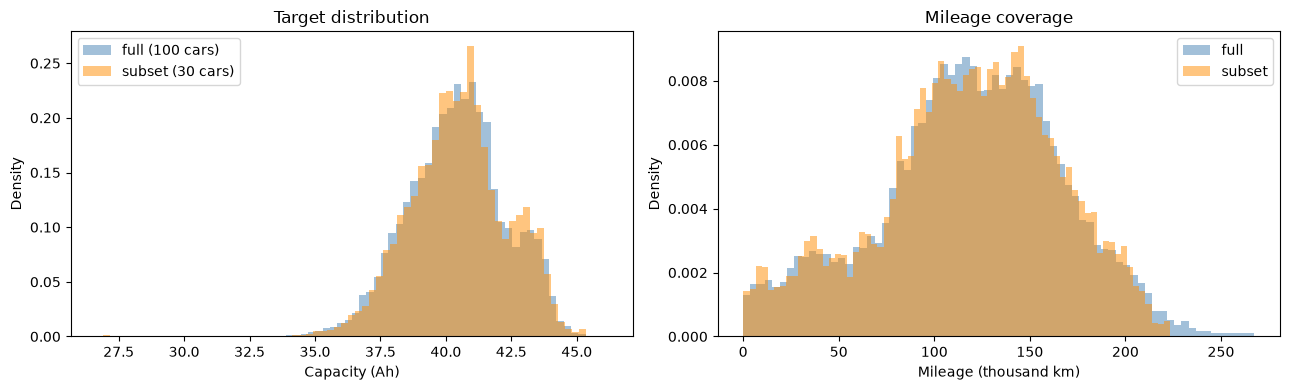

In [4]:
# Side-by-side distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(snips["capacity"], bins=70, density=True, alpha=0.5,
             label="full (100 cars)", color="steelblue")
axes[0].hist(sub_snips["capacity"], bins=70, density=True, alpha=0.5,
             label=f"subset ({N_CARS} cars)", color="darkorange")
axes[0].set_xlabel("Capacity (Ah)"); axes[0].set_ylabel("Density")
axes[0].set_title("Target distribution"); axes[0].legend()

axes[1].hist(snips["mileage"] / 1000, bins=70, density=True, alpha=0.5,
             label="full", color="steelblue")
axes[1].hist(sub_snips["mileage"] / 1000, bins=70, density=True, alpha=0.5,
             label="subset", color="darkorange")
axes[1].set_xlabel("Mileage (thousand km)"); axes[1].set_ylabel("Density")
axes[1].set_title("Mileage coverage"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "subset_representativeness.png", dpi=150, bbox_inches="tight")
plt.show()

**The left tail is disconnected, not thin.** The histogram shows a small isolated
cluster near 27–28 Ah, then an empty gap until ~34 Ah where the main distribution
begins. So the 26.64 Ah minimum is an outlier island rather than the end of a
continuous tail — there are almost no training examples in the 28–34 Ah transition
region. Expect all models to fail on these points; a model cannot interpolate into a
region it has never seen. This likely explains the reference paper's observation that
all their models struggled at capacity extremes.

## 2. Fold assignment

### Why k-fold rather than a single split

With 30 vehicles and an 80/20 split, the test set would be 6 vehicles. Given the 23×
imbalance in snippet counts and the distinct per-vehicle trajectories, the headline
number would depend heavily on *which* 6 vehicles landed in test — plausibly a larger
effect than the LSTM-vs-Transformer difference being measured.

The reference paper hit exactly this: a single vehicle accounted for roughly 70% of
their worst-error cases, and removing it moved their metrics by about 5%.

With 5-fold CV each vehicle appears in test exactly once, and results come with a
**standard deviation across folds** — which is what determines whether a gap between
two models is real or noise.

### Balancing the folds

Random fold assignment would produce uneven folds given the 23× spread in snippet
counts. Instead, vehicles are sorted by snippet count descending and each is assigned
to whichever fold currently holds the fewest snippets — a standard greedy load-balancing
heuristic that yields far more even folds than random assignment.

**Development uses fold 0 only.** Full 5-fold runs are reserved for final reported
results, so debugging and hyperparameter iteration stay fast.

In [5]:
# Greedy balanced assignment: largest vehicles first, each to the lightest fold.

fold_of = {}
fold_load = {k: 0 for k in range(N_FOLDS)}

for _, row in subset.sort_values("n_snippets", ascending=False).iterrows():
    target = min(fold_load, key=fold_load.get)
    fold_of[int(row["car"])] = target
    fold_load[target] += int(row["n_snippets"])

subset["fold"] = subset["car"].map(fold_of)

fold_summary = subset.groupby("fold").agg(
    n_cars=("car", "count"),
    n_snippets=("n_snippets", "sum"),
    cars=("car", lambda s: sorted(s.tolist())),
)

print(fold_summary[["n_cars", "n_snippets"]])
print()
spread = fold_summary["n_snippets"].max() / fold_summary["n_snippets"].min()
print(f"Largest/smallest fold ratio: {spread:.2f}x  (1.00 would be perfectly even)")
print()
for f, row in fold_summary.iterrows():
    print(f"  fold {f}: {row['cars']}")

      n_cars  n_snippets
fold                    
0          6       22263
1          6       22103
2          6       22590
3          6       22127
4          6       22193

Largest/smallest fold ratio: 1.02x  (1.00 would be perfectly even)

  fold 0: [21, 43, 63, 69, 105, 111]
  fold 1: [5, 18, 50, 118, 134, 150]
  fold 2: [7, 41, 53, 60, 131, 175]
  fold 3: [4, 23, 68, 87, 156, 184]
  fold 4: [2, 3, 49, 57, 136, 166]


In [6]:
# Per-fold target statistics — folds should be comparable, not just equal in size.

sub_snips["fold"] = sub_snips["car"].map(fold_of)

fold_stats = sub_snips.groupby("fold").agg(
    n=("capacity", "size"),
    cap_mean=("capacity", "mean"),
    cap_std=("capacity", "std"),
    cap_min=("capacity", "min"),
    mileage_mean_k=("mileage", lambda s: s.mean() / 1000),
).round(3)

fold_stats

,n,cap_mean,cap_std,cap_min,mileage_mean_k
fold,,,,,
0,22263,40.769,1.745,33.322,109.755
1,22103,40.400,1.706,32.738,117.810
2,22590,40.974,1.895,26.641,117.303
3,22127,40.040,1.810,31.971,126.049
4,22193,40.280,1.991,33.620,116.767


### Interpretation — folds balanced on size, variable in difficulty

**Size: 22,103 – 22,590 snippets (1.02× ratio).** Greedy assignment worked; folds are
near-perfectly even despite the 20× spread in per-vehicle snippet counts.

**But the folds are not equally hard:**

| | Range | Implication |
|---|---|---|
| `cap_mean` | 40.04 – 40.97 | 0.93 Ah spread — half the overall std |
| `cap_std` | 1.706 – 1.991 | 17% spread — **each fold has a different baseline floor** |

Since a mean predictor's RMSE equals the target std, fold 1 (std 1.706) is
intrinsically easier than fold 4 (std 1.991). **Per-fold RMSE is therefore not directly
comparable across folds** — a model scoring 1.75 on fold 1 and 1.85 on fold 4 may be
performing better on fold 4. Compare each fold against its own baseline, or use R²,
which normalises against exactly this.

**The degraded outliers are confined to fold 2** (`cap_min` 26.641 vs 31.9–33.6
elsewhere). The isolated 27–28 Ah cluster sits in a single fold, so in four runs those
extremes are in training and in one they are in test with no comparable training
examples. **Expect fold 2 to produce the worst errors**, concentrated on few snippets.
This is the local equivalent of the reference paper's single-vehicle error
concentration, identified in advance rather than after the fact.

## 3. Save the fold manifest

Written to disk so the split is **fixed and reproducible**. Every subsequent notebook,
training script and evaluation run loads this file rather than re-deriving a split.

This is what makes the LSTM, Transformer and baselines genuinely comparable.

In [7]:
manifest = {
    "config": {
        "n_cars": N_CARS,
        "n_folds": N_FOLDS,
        "random_seed": RANDOM_SEED,
        "selection": "stratified by snippet count, one vehicle per stratum",
        "fold_assignment": "greedy balanced by snippet count",
    },
    "folds": {
        str(f): sorted(int(c) for c in subset.loc[subset["fold"] == f, "car"])
        for f in range(N_FOLDS)
    },
    "car_to_fold": {str(k): int(v) for k, v in fold_of.items()},
    "files": {
        str(c): car_to_files[str(c)] for c in sorted(subset["car"])
    },
}

manifest_path = INDEX_DIR / "fold_manifest.json"
with open(manifest_path, "w") as fp:
    json.dump(manifest, fp, indent=2)

subset.to_csv(INDEX_DIR / "subset_cars.csv", index=False)

print(f"Saved → {manifest_path}")
print(f"Saved → {INDEX_DIR / 'subset_cars.csv'}")
print(f"\nTotal snippets in working set: "
      f"{sum(len(v) for v in manifest['files'].values()):,}")

Saved → ../data/processed/fold_manifest.json
Saved → ../data/processed/subset_cars.csv

Total snippets in working set: 111,276


## 4. Out-of-sample baselines

Both baselines, evaluated properly: fitted on the training vehicles of each fold and
scored on the held-out vehicles.

**Baseline 1 — mean predictor.** Predicts the *training* fold's mean for every test
snippet. Uses no input. Establishes the floor.

**Baseline 2 — mileage-only linear regression.** One feature: the odometer reading.
Fitted on training vehicles, predicts on unseen ones.

> Note that the mean baseline's RMSE will no longer exactly equal the target standard
> deviation, as it did in-sample. It predicts the *training* mean against the *test*
> distribution, so any difference between fold means adds error.

In [8]:
def metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "r2": float(r2_score(y_true, y_pred)),
    }


records = []

for fold in range(N_FOLDS):
    test_mask = sub_snips["fold"] == fold
    train, test = sub_snips[~test_mask], sub_snips[test_mask]

    y_train, y_test = train["capacity"].values, test["capacity"].values
    X_train = train[["mileage"]].values
    X_test = test[["mileage"]].values

    # --- mean predictor -----------------------------------------------------
    m = metrics(y_test, np.full_like(y_test, y_train.mean()))
    records.append({"model": "Mean baseline", "fold": fold, **m})

    # --- mileage-only linear regression -------------------------------------
    lr = LinearRegression().fit(X_train, y_train)
    m = metrics(y_test, lr.predict(X_test))
    records.append({"model": "Linear (mileage)", "fold": fold,
                    "slope_per_1k_km": float(lr.coef_[0] * 1000), **m})

per_fold = pd.DataFrame(records)
per_fold.round(3)

,model,fold,rmse,mae,mape,r2,slope_per_1k_km
0,Mean baseline,0,1.778,1.378,3.377,-0.039,NaN
1,Linear (mileage),0,1.032,0.822,2.043,0.650,-0.032
2,Mean baseline,1,1.711,1.396,3.465,-0.005,NaN
3,Linear (mileage),1,1.081,0.864,2.166,0.599,-0.032
4,Mean baseline,2,1.988,1.510,3.669,-0.101,NaN
5,Linear (mileage),2,1.379,0.985,2.413,0.471,-0.032
6,Mean baseline,3,1.897,1.496,3.819,-0.098,NaN
7,Linear (mileage),3,0.815,0.538,1.382,0.797,-0.031
8,Mean baseline,4,2.009,1.649,4.152,-0.018,NaN
9,Linear (mileage),4,1.166,0.851,2.173,0.657,-0.033


In [9]:
# Aggregate: mean +/- std across folds. The std is what tells us whether a gap
# between two models is real or just fold-to-fold noise.

agg = per_fold.groupby("model")[["rmse", "mae", "mape", "r2"]].agg(["mean", "std"])
agg = agg.round(3)

print(agg)
print()

for model in per_fold["model"].unique():
    d = per_fold[per_fold["model"] == model]
    print(f"{model:<20} RMSE {d['rmse'].mean():.3f} ± {d['rmse'].std():.3f}   "
          f"(range {d['rmse'].min():.3f} - {d['rmse'].max():.3f})")

print(f"\nReference paper's LSTM (held out): RMSE 1.420, MAE 1.090, MAPE 2.70%")

                   rmse           mae          mape            r2       
                   mean    std   mean    std   mean    std   mean    std
model                                                                   
Linear (mileage)  1.095  0.205  0.812  0.165  2.036  0.389  0.635  0.118
Mean baseline     1.877  0.130  1.486  0.108  3.696  0.308 -0.052  0.045

Mean baseline        RMSE 1.877 ± 0.130   (range 1.711 - 2.009)
Linear (mileage)     RMSE 1.095 ± 0.205   (range 0.815 - 1.379)

Reference paper's LSTM (held out): RMSE 1.420, MAE 1.090, MAPE 2.70%


### Interpretation — the mileage baseline holds up out-of-sample

| Model | RMSE (mean ± std) | Range across folds |
|---|---|---|
| Mean baseline | 1.877 ± 0.13 | 1.711 – 2.009 |
| **Linear (mileage)** | **1.095 ± 0.21** | **0.815 – 1.379** |
| *Reference paper LSTM* | *1.420* | *single split* |

**Finding 5 survives fair comparison.** The mileage-only baseline beats the published
LSTM on **all five held-out folds** — even fold 2, the hardest, comes in at 1.379. The
in-sample figure (1.117) was not optimistic; the properly evaluated mean is 1.095.

**Fold 2 behaved as predicted.** Worst on both models (1.988 / 1.379) and the only fold
where R² falls below 0.5. This is the fold holding the isolated 27–28 Ah cluster,
identified before any model was run.

**Fold 3 is unusually easy** (RMSE 0.815, R² 0.797). It has the highest mean mileage
(126.0k) and lowest mean capacity — vehicles further along their degradation curves,
where the mileage-capacity relationship is most linear.

**Fold-to-fold std ≈ 0.21 RMSE is the significance threshold.** Any difference between
the LSTM and Transformer smaller than this cannot be called real. For context, that
spread exceeds the gap between the reference paper's best and second-best models.

**Negative R² on the mean baseline** (folds 2 and 3) is expected, not a bug: the
training-fold mean is predicted against a test distribution with a different mean.
Fold means range 40.04 – 40.97, so the mismatch is enough to score worse than
predicting the test set's own mean. Further evidence that fold composition genuinely
varies — the reason for cross-validating.

**Slope is remarkably stable** (−0.031 to −0.033 Ah per 1,000 km across all folds),
confirming the degradation rate is a property of the fleet, not of any particular
vehicle subset.

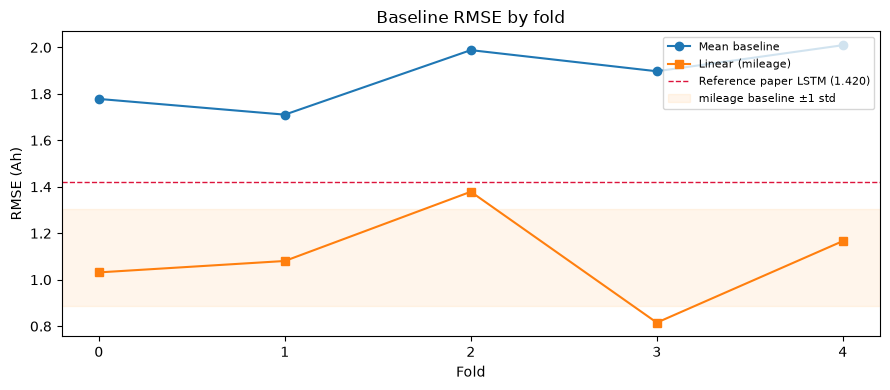

In [11]:
# Per-fold variation, visualised.
# A wide spread here is itself a finding: it quantifies how much a single-split
# result could have drifted purely by luck of the draw.

fig, ax = plt.subplots(figsize=(9, 4))

for model, marker in [("Mean baseline", "o"), ("Linear (mileage)", "s")]:
    d = per_fold[per_fold["model"] == model]
    ax.plot(d["fold"], d["rmse"], marker=marker, label=model)

ax.axhline(1.420, color="crimson", ls="--", lw=1,
           label="Reference paper LSTM (1.420)")
ax.axhspan(1.095 - 0.21, 1.095 + 0.21, color="darkorange", alpha=0.08,
           label="mileage baseline ±1 std")
ax.set_xlabel("Fold"); ax.set_ylabel("RMSE (Ah)")
ax.set_xticks(range(N_FOLDS))
ax.set_title("Baseline RMSE by fold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_by_fold.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — the mileage baseline holds up out-of-sample

| Model | RMSE (mean ± std) | Range |
|---|---|---|
| Mean baseline | 1.877 ± 0.13 | 1.711 – 2.009 |
| **Linear (mileage)** | **1.095 ± 0.21** | **0.815 – 1.379** |
| *Reference paper LSTM* | *1.420* | *single split* |

**Finding 5 survives fair comparison.** The mileage baseline beats the published LSTM
on **all five held-out folds** — even fold 2, the hardest, clears it at 1.379. The
in-sample 1.117 was not optimistic.

**Fold 2 behaved as predicted** (worst on both models, R² 0.471). It holds the isolated
27–28 Ah cluster, flagged before any model was run. **Fold 3 is unusually easy** (0.815,
R² 0.797) — its vehicles sit further along their degradation curves, where the
mileage–capacity relationship is most linear.

**Both lines move together**, so per-fold RMSE reflects fold difficulty as much as model
quality. Use R² for cross-fold comparison.

**The shaded band (±0.21) is the significance threshold.** Any LSTM-vs-Transformer gap
falling inside it cannot be called real — for context, that exceeds the gap between the
reference paper's best and second-best models.

**Negative R² on the mean baseline** is expected: the training-fold mean is predicted
against a test distribution with a different mean (fold means span 40.04 – 40.97).

> Re-plot with LSTM and Transformer once trained — four lines against the red reference
> makes the central result readable in one image.

## 5. Baseline by mileage band

Notebook 02, Findings 3 and 3b predicted that the mileage baseline should be strongest
at low mileage (where every vehicle sits at 43.33 ± 0.78) and weakest at high mileage
(spread 1.38, only 4.1% of data).

Establishing the per-band baseline now gives the sequence models a **band-level**
reference, not just an aggregate one — which is where the hypothesised advantage should
appear if it exists at all.

In [12]:
band_records = []
bins = [0, 50, 100, 150, 200, 300]

for fold in range(N_FOLDS):
    test_mask = sub_snips["fold"] == fold
    train, test = sub_snips[~test_mask], sub_snips[test_mask].copy()

    lr = LinearRegression().fit(train[["mileage"]].values, train["capacity"].values)
    test["pred"] = lr.predict(test[["mileage"]].values)
    test["band"] = pd.cut(test["mileage"] / 1000, bins=bins)

    for band, g in test.groupby("band", observed=True):
        if len(g) < 50:      # skip bands too small to be meaningful
            continue
        band_records.append({
            "band": str(band), "fold": fold, "n": len(g),
            **metrics(g["capacity"].values, g["pred"].values),
        })

bands = pd.DataFrame(band_records)

band_agg = bands.groupby("band").agg(
    folds=("fold", "nunique"),
    n_total=("n", "sum"),
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    mae_mean=("mae", "mean"),
).round(3)

band_agg

,folds,n_total,rmse_mean,rmse_std,mae_mean
band,,,,,
"(0, 50]",5,11860,0.777,0.138,0.608
"(100, 150]",5,46047,0.968,0.291,0.744
"(150, 200]",5,25718,1.409,0.250,1.061
"(200, 300]",4,2935,1.178,0.348,0.866
"(50, 100]",5,24716,0.999,0.265,0.760


### Interpretation — the odometer is weakest at 150–200k km, not at the extreme

| Band (k km) | n_total | RMSE | ±std | MAE |
|---|---|---|---|---|
| 0–50 | 11,860 | **0.777** | 0.138 | 0.608 |
| 50–100 | 24,716 | 0.999 | 0.265 | 0.760 |
| 100–150 | 46,047 | 0.968 | 0.291 | 0.744 |
| **150–200** | 25,718 | **1.409** | 0.250 | 1.061 |
| 200–300 | 2,935 | 1.178 | 0.348 | 0.866 |

**Finding 3 partly confirmed.** As predicted, the baseline is strongest at low mileage
(0.777, and the tightest fold spread at ±0.138) — at 0–50k every vehicle sits at
43.33 ± 0.78, so the odometer is nearly sufficient and there is little room to improve.

**But error peaks at 150–200k (1.409), not at the highest band.** Performance recovers
to 1.178 above 200k. The odometer decouples from capacity most in the 150–200k range,
not among the oldest vehicles.

**Revised target for the sequence models: the 150–200k band.** It combines the weakest
baseline with ample data (25,718 snippets), making it the cleanest place to test
whether charging behaviour adds information the odometer lacks.

**The 200–300k figure is unreliable.** Only 4 of 5 folds contributed (one had fewer
than 50 test snippets), n = 2,935, and it carries the largest fold spread (±0.348).
Indicative only; claims drawn from it should be correspondingly weak.

**Aggregate RMSE would have hidden all of this.** 41% of snippets sit in the 100–150k
band where the baseline performs near its average, so the 1.409 weak spot is diluted
away. Per-band evaluation is required, not optional.

In [13]:
# Persist baseline results for the final comparison table.

RESULTS_DIR = Path("../reports")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

per_fold.to_csv(RESULTS_DIR / "baselines_per_fold.csv", index=False)
bands.to_csv(RESULTS_DIR / "baselines_per_band.csv", index=False)

print(f"Saved → {RESULTS_DIR / 'baselines_per_fold.csv'}")
print(f"Saved → {RESULTS_DIR / 'baselines_per_band.csv'}")

Saved → ../reports/baselines_per_fold.csv
Saved → ../reports/baselines_per_band.csv


## Summary

**Configuration**

| Setting | Value |
|---|---|
| Vehicles | 30, stratified by snippet count |
| Snippets | 111,276 (31.8% of full set) |
| Folds | 5, balanced by snippet count (22,103 – 22,590 each) |
| Split level | Vehicle (never snippet) |
| Seed | 42 |

**Findings**

| # | Finding |
|---|---|
| 6 | Subset preserves the target distribution: std 1.863 → 1.864, min 26.641 unchanged, r −0.800 → −0.810. Capacity ceiling drops to 45.35 Ah and mileage ceiling to 223k km. |
| 7 | Folds are even in size (1.02× ratio) but **not equal in difficulty**: `cap_std` spans 1.706–1.991, so each fold has its own baseline floor. Use R² for cross-fold comparison. |
| 8 | The isolated 27–28 Ah cluster sits entirely in **fold 2** — predicted to produce the worst errors, and it did. |
| 9 | **Finding 5 survives fair evaluation.** Mileage-only baseline beats the published LSTM (1.420) on all five held-out folds. |
| 10 | **Fold-to-fold std is ±0.21 RMSE** — the significance threshold for all later model comparisons. |
| 11 | The odometer is weakest at **150–200k km** (RMSE 1.409), not at the highest band. Revised target for the sequence models. |

**Out-of-sample baselines**

| Model | Inputs | RMSE | MAE | MAPE | R² |
|---|---|---|---|---|---|
| Mean baseline | none | 1.877 ± 0.13 | 1.486 | 3.70% | −0.052 |
| **Linear regression** | **mileage** | **1.095 ± 0.21** | **0.812** | **2.04%** | **0.635** |
| LSTM | 128×8 sequence | | | | |
| Transformer | 128×8 sequence | | | | |
| *Reference paper LSTM* | *128×8 sequence* | *1.420* | *1.090* | *2.70%* | *—* |

**Per-band baseline (mileage-only) — the real target**

| Band (k km) | n | RMSE |
|---|---|---|
| 0–50 | 11,860 | 0.777 |
| 50–100 | 24,716 | 0.999 |
| 100–150 | 46,047 | 0.968 |
| **150–200** | **25,718** | **1.409** |
| 200–300 | 2,935 | 1.178 *(4 folds only, unreliable)* |

**Artefacts written**

| File | Contents |
|---|---|
| `data/processed/fold_manifest.json` | Fold assignment + file paths per vehicle |
| `data/processed/subset_cars.csv` | The 30 selected vehicles with fold labels |
| `reports/baselines_per_fold.csv` | Out-of-sample baseline metrics per fold |
| `reports/baselines_per_band.csv` | Baseline metrics per mileage band |
| `reports/figures/subset_representativeness.png` | Subset vs full distributions |
| `reports/figures/baseline_by_fold.png` | Fold-to-fold RMSE variation |

---

### What the sequence models must do

Not "beat 1.420" — that bar is already cleared by one feature. The question is whether
charging behaviour adds information the odometer lacks:

1. **Beat 1.095 ± 0.21 in aggregate**, using only the 128×8 window and no mileage
2. **Specifically beat 1.409 in the 150–200k band**, where the odometer is weakest and
   data is plentiful
3. Any gap smaller than 0.21 RMSE is noise, not a result

---

**Next:** `04_dataset_and_lstm.ipynb` — a lazy-loading PyTorch `Dataset` reading from
the fold manifest, normalisation fitted on training folds only, and the LSTM baseline
reproducing the reference architecture.